In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
!pip install optuna

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [89]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [90]:
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score
from sklearn.preprocessing import StandardScaler,RobustScaler,LabelEncoder
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report,roc_curve,precision_recall_curve)

import xgboost as xgb
import optuna
# import shap
import warnings
warnings.filterwarnings('ignore')

In [91]:
df=pd.read_csv("urban_street_food_vendor_survival_dataset.csv")


In [92]:
df.head()

,vendor_id,city,zone_type,vendor_age_years,years_in_business,food_category,license_status,avg_daily_revenue_inr,avg_daily_customers,monthly_stall_rent_inr,num_helpers,hours_open_per_day,competition_within_100m,monthly_health_inspection_score,had_fine_last_year,avg_monthly_rainfall_mm,season_of_observation,has_online_presence,customer_complaint_rate,vendor_survived
0,VSF-00001,Delhi,Industrial,34.0,10.98,Chinese,Licensed,332.20,10.0,0.00,1,10.00,4.0,65.00,0.0,103.08,Winter,0.0,0.12,1
1,VSF-00002,Kochi,University Area,33.0,5.53,Chaat,Licensed,3138.90,180.0,2112.10,1,6.42,3.0,NaN,1.0,350.00,Monsoon,1.0,0.22,1
2,VSF-00003,Hyderabad,Industrial,48.0,2.70,Desserts & Sweets,Licensed,1626.36,67.0,5487.75,3,11.80,0.0,NaN,0.0,66.64,Post-Monsoon,0.0,0.09,0
3,VSF-00004,Bengaluru,Transit Hub,NaN,9.77,Beverages,Licensed,3592.98,171.0,1960.79,3,12.53,NaN,36.38,1.0,107.30,Post-Monsoon,1.0,0.10,1
4,VSF-00005,Delhi,Transit Hub,51.0,21.24,South Indian,Licensed,2418.07,105.0,2720.82,4,6.07,5.0,71.05,0.0,166.57,Monsoon,0.0,0.08,0


In [93]:
df.shape

(22000, 20)

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   vendor_id                        22000 non-null  object 
 1   city                             22000 non-null  object 
 2   zone_type                        22000 non-null  object 
 3   vendor_age_years                 21242 non-null  float64
 4   years_in_business                20963 non-null  float64
 5   food_category                    22000 non-null  object 
 6   license_status                   21350 non-null  object 
 7   avg_daily_revenue_inr            20062 non-null  float64
 8   avg_daily_customers              20747 non-null  float64
 9   monthly_stall_rent_inr           20890 non-null  float64
 10  num_helpers                      22000 non-null  int64  
 11  hours_open_per_day               21558 non-null  float64
 12  competition_within

In [95]:
df.describe()

,vendor_age_years,years_in_business,avg_daily_revenue_inr,avg_daily_customers,monthly_stall_rent_inr,num_helpers,hours_open_per_day,competition_within_100m,monthly_health_inspection_score,had_fine_last_year,avg_monthly_rainfall_mm,has_online_presence,customer_complaint_rate,vendor_survived
count,21242.000000,20963.000000,20062.000000,20747.000000,20890.000000,22000.000000,21558.000000,21116.000000,14241.000000,21779.000000,22000.000000,21807.000000,19580.000000,22000.000000
mean,37.172630,10.504471,2391.236096,92.101894,3734.974200,0.727955,9.514866,7.033482,57.524752,0.273015,138.258154,0.181134,0.156073,0.425636
std,10.513603,7.861512,4034.506720,74.155636,2483.854752,1.127912,2.668487,4.921401,21.593580,0.445519,91.516023,0.385138,0.084183,0.494450
min,20.000000,0.500000,185.410000,1.000000,0.000000,0.000000,6.000000,0.000000,20.000000,0.000000,5.000000,0.000000,0.010000,0.000000
25%,28.000000,3.940000,981.422500,45.000000,1647.947500,0.000000,6.990000,3.000000,39.190000,0.000000,68.830000,0.000000,0.080000,0.000000
50%,37.000000,8.520000,1516.590000,74.000000,3770.905000,0.000000,10.030000,6.000000,57.420000,0.000000,106.025000,0.000000,0.160000,0.000000
75%,46.000000,15.800000,2390.127500,115.000000,5891.525000,1.000000,12.030000,9.000000,75.720000,1.000000,230.282500,0.000000,0.230000,1.000000
max,75.000000,56.260000,39997.330000,400.000000,7999.640000,5.000000,14.000000,19.000000,95.000000,1.000000,350.000000,1.000000,0.300000,1.000000


Check target variable distribution

In [96]:
print("Target Variable Distribution:")
print("-"*50)

survival_count=df['vendor_survived'].value_counts()
print(survival_count)

print(f"Survival Rate : {survival_count[1]/len(df)*100:.2f}%")

Target Variable Distribution:
--------------------------------------------------
vendor_survived
0    12636
1     9364
Name: count, dtype: int64
Survival Rate : 42.56%


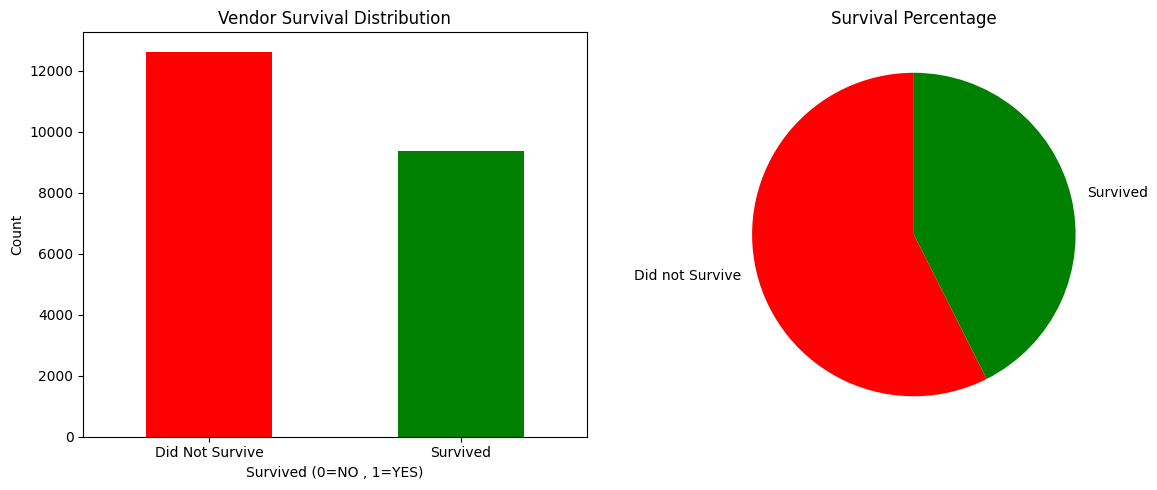

In [97]:
from matplotlib import colors
fig,axes=plt.subplots(1,2,figsize=(12,5))

#Bar Chart

survival_count.plot(kind='bar',ax=axes[0],color=['red','green'])
axes[0].set_title('Vendor Survival Distribution')
axes[0].set_xlabel('Survived (0=NO , 1=YES)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(["Did Not Survive","Survived"],rotation=0)

#Pie Chart

axes[1].pie(survival_count,labels=["Did not Survive","Survived"],colors=["red","green"],startangle=90)

axes[1].set_title("Survival Percentage")

plt.tight_layout()
plt.show()


EDA :

In [98]:
df.isnull().sum()

vendor_id                             0
city                                  0
zone_type                             0
vendor_age_years                    758
years_in_business                  1037
food_category                         0
license_status                      650
avg_daily_revenue_inr              1938
avg_daily_customers                1253
monthly_stall_rent_inr             1110
num_helpers                           0
hours_open_per_day                  442
competition_within_100m             884
monthly_health_inspection_score    7759
had_fine_last_year                  221
avg_monthly_rainfall_mm               0
season_of_observation                 0
has_online_presence                 193
customer_complaint_rate            2420
vendor_survived                       0
dtype: int64

In [99]:
missing_data=df.isnull().sum()
missing_percentage=(missing_data/len(df))*100

missing_df=pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percentage
}).sort_values('Missing Percentage',ascending=False)

print("Missing Value Analysis :")
print(missing_df[missing_df['Missing Count']>0])

Missing Value Analysis :
                                 Missing Count  Missing Percentage
monthly_health_inspection_score           7759           35.268182
customer_complaint_rate                   2420           11.000000
avg_daily_revenue_inr                     1938            8.809091
avg_daily_customers                       1253            5.695455
monthly_stall_rent_inr                    1110            5.045455
years_in_business                         1037            4.713636
competition_within_100m                    884            4.018182
vendor_age_years                           758            3.445455
license_status                             650            2.954545
hours_open_per_day                         442            2.009091
had_fine_last_year                         221            1.004545
has_online_presence                        193            0.877273


For Numerical Columns :

In [100]:
num_cols=[
    'vendor_age_years','years_in_business','avg_daily_revenue_inr','avg_daily_customers','monthly_stall_rent_inr','hours_open_per_day','competition_within_100m','customer_complaint_rate'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

For Categorical Columns :

In [101]:
cat_cols = ['license_status']
df[cat_cols] = df[cat_cols].apply(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else "Unknown")
)

In [102]:
df['monthly_health_inspection_score'] = df['monthly_health_inspection_score'].fillna(
    df['monthly_health_inspection_score'].median()
)

In [103]:
df['had_fine_last_year'] = df['had_fine_last_year'].fillna(0)

In [104]:
df.isnull().sum()

vendor_id                            0
city                                 0
zone_type                            0
vendor_age_years                     0
years_in_business                    0
food_category                        0
license_status                       0
avg_daily_revenue_inr                0
avg_daily_customers                  0
monthly_stall_rent_inr               0
num_helpers                          0
hours_open_per_day                   0
competition_within_100m              0
monthly_health_inspection_score      0
had_fine_last_year                   0
avg_monthly_rainfall_mm              0
season_of_observation                0
has_online_presence                193
customer_complaint_rate              0
vendor_survived                      0
dtype: int64

In [105]:
numerical_cols = ['vendor_age_years', 'years_in_business', 'avg_daily_revenue_inr',
                  'avg_daily_customers', 'monthly_stall_rent_inr', 'num_helpers',
                  'hours_open_per_day', 'competition_within_100m',
                  'monthly_health_inspection_score', 'customer_complaint_rate']


In [106]:
categorical_cols = ['city', 'zone_type', 'food_category', 'license_status',
                    'season_of_observation', 'has_online_presence', 'had_fine_last_year']

In [107]:
numerical_df=df[numerical_cols + ['vendor_survived']].copy()

numerical_df=numerical_df.fillna(numerical_df.median())

corr_matrix=numerical_df.corr()

target_corr=corr_matrix['vendor_survived'].sort_values(ascending=False)
print("\nTop Correlations with Survival :")
print(target_corr)


Top Correlations with Survival :
vendor_survived                    1.000000
avg_daily_revenue_inr              0.180710
avg_daily_customers                0.162235
monthly_health_inspection_score    0.091603
monthly_stall_rent_inr             0.003980
vendor_age_years                  -0.001885
years_in_business                 -0.002226
hours_open_per_day                -0.005639
num_helpers                       -0.018467
competition_within_100m           -0.051773
customer_complaint_rate           -0.087287
Name: vendor_survived, dtype: float64


Data Cleaning And preprocessing :

In [108]:
def clean_data(df):
  df_clean=df.copy()

  if 'vendor_id' in df_clean.columns:
    df_clean=df_clean.drop('vendor_id',axis=1)

  df_clean['vendor_age_years']=df_clean['vendor_age_years'].replace(0,np.nan)

  df_clean['had_fine_last_year']=df_clean['had_fine_last_year'].fillna(0).astype(int)
  df_clean['has_online_presence']=df_clean['has_online_presence'].fillna(0).astype(int)

  for col in numerical_cols:
    if col in df_clean.columns:

      upper=df_clean[col].quantile(0.99)
      df_clean[col]=df_clean[col].clip(upper=upper)

      lower=df_clean[col].quantile(0.01)
      df_clean[col]=df_clean[col].clip(lower=lower)

    return df_clean

df_clean=clean_data(df)
print("Data Cleaning Completed !!")
print(f"Original shape : {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")

Data Cleaning Completed !!
Original shape : (22000, 20)
Cleaned shape: (22000, 19)


In [109]:
df.isnull().sum()

vendor_id                            0
city                                 0
zone_type                            0
vendor_age_years                     0
years_in_business                    0
food_category                        0
license_status                       0
avg_daily_revenue_inr                0
avg_daily_customers                  0
monthly_stall_rent_inr               0
num_helpers                          0
hours_open_per_day                   0
competition_within_100m              0
monthly_health_inspection_score      0
had_fine_last_year                   0
avg_monthly_rainfall_mm              0
season_of_observation                0
has_online_presence                193
customer_complaint_rate              0
vendor_survived                      0
dtype: int64

Feature Engineering :

In [110]:
def create_features(df):
  df_feat=df.copy()

  df_feat['revenue_per_customer']=df_feat['avg_daily_revenue_inr'] / (df_feat['avg_daily_customers']+1)
  df_feat['revenue_per_helper']=df_feat['avg_daily_revenue_inr'] / (df_feat['num_helpers']+1)
  df_feat['customers_per_helper']=df_feat['avg_daily_customers'] / (df_feat['num_helpers']+1)

  df_feat['customers_per_hour']=df_feat['avg_daily_customers'] / (df_feat['hours_open_per_day'] + 1)
  df_feat['revenue_per_hour']=df_feat['avg_daily_revenue_inr'] / (df_feat['hours_open_per_day'] + 1)

  df_feat['age_at_start']=df_feat['vendor_age_years'] - df_feat['years_in_business']
  df_feat['experience_ratio']=df_feat['years_in_business'] / (df_feat['vendor_age_years']+1)

  df_feat['competition_per_customer']=df_feat['competition_within_100m'] / (df_feat['avg_daily_customers']+1)
  df_feat['market_saturation']=df_feat['competition_within_100m'] * df_feat['hours_open_per_day']

  df_feat['monthly_revenue']=df_feat['avg_daily_revenue_inr'] * 30
  df_feat['profit_estimate']=df_feat['monthly_revenue'] - df_feat['monthly_stall_rent_inr']
  df_feat['profit_margin']=df_feat['profit_estimate'] / (df_feat['monthly_revenue'] + 1)

  df_feat['health_score_normalized']=df_feat['monthly_health_inspection_score'] / 100
  df_feat['compliance_risk']=df_feat['had_fine_last_year'] * (1 - df_feat['health_score_normalized'])

  df_feat['satisfaction_score']=1-df_feat['customer_complaint_rate']
  df_feat['revenue_per_complaint']=df_feat['avg_daily_revenue_inr'] / (df_feat['customer_complaint_rate']+ 0.01)

  df_feat['rent_to_revenue_ratio']=df_feat['monthly_stall_rent_inr'] / (df_feat['monthly_revenue']+1)

  return df_feat

df_features=create_features(df_clean)
print(f"Features Created ! New Shape :{df_features.shape}")
print(f"New Features added : {len(df_features.columns)-len(df_clean.columns)}")

Features Created ! New Shape :(22000, 36)
New Features added : 17


In [111]:
!pip uninstall -y numpy scikit-learn scipy

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scikit-learn 1.3.2
Uninstalling scikit-learn-1.3.2:
  Successfully uninstalled scikit-learn-1.3.2
Found existing installation: scipy 1.11.4
Uninstalling scipy-1.11.4:
  Successfully uninstalled scipy-1.11.4


In [112]:
!pip install numpy==1.26.4
!pip install scipy==1.11.4
!pip install scikit-learn==1.3.2

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for numpy==1.26.4 from https://files.pythonhosted.org/packages/16/2e/86f24451c2d530c88daf997cb8d6ac622c1d40d19f5a031ed68a4b73a374/numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata
  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires scikit-learn, which is not installed.
shap 0.51.0 requires scipy, which is not installed.
statsmodels 0.14.5 requires scipy!=1.9.2,>=1.8, which is not installed.
xgboost 1.7.6 requires scipy, which is not installed.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for scipy==1.11.4 from https://files.pythonhosted.org/packages/c6/a1/357e4cd43af2748e1e0407ae0e9a5ea8aaaa6b702833c81be11670dcbad8/scipy-1.11.4-cp312-cp312-win_amd64.whl.metadata
  Using cached scipy-1.11.4-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.11.4-cp312-cp312-win_amd64.whl (43.7 MB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires scikit-learn, which is not installed.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for scikit-learn==1.3.2 from https://files.pythonhosted.org/packages/fe/6b/db949ed5ac367987b1f250f070f340b7715d22f0c9c965bdf07de6ca75a3/scikit_learn-1.3.2-cp312-cp312-win_amd64.whl.metadata
  Using cached scikit_learn-1.3.2-cp312-cp312-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.3.2-cp312-cp312-win_amd64.whl (9.1 MB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Prepare Data for Modeling :

In [113]:
x=df_features.drop('vendor_survived',axis=1)
y=df_features['vendor_survived']

print("Missing values before imputation:")
print(x.isnull().sum().sort_values(ascending=False).head(10))

#Use KNN imputer for numerical features
from sklearn.impute import KNNImputer

numerical_cols_list=x.select_dtypes(include=[np.number]).columns.tolist()

imputer=KNNImputer(n_neighbors=5)
x_imputed=pd.DataFrame(
    imputer.fit_transform(x[numerical_cols_list]),
    columns=numerical_cols_list,
    index=x.index
)

categorical_cols_list=x.select_dtypes(include=['object']).columns.tolist()
if categorical_cols_list:
  x_final=pd.concat([x_imputed,x[categorical_cols_list]],axis=1)
else:
  x_final=x_imputed

print(f"Missing values after imputation : {x_final.isnull().sum().sum()}")

Missing values before imputation:
city                        0
market_saturation           0
customers_per_helper        0
customers_per_hour          0
revenue_per_hour            0
age_at_start                0
experience_ratio            0
competition_per_customer    0
monthly_revenue             0
revenue_per_customer        0
dtype: int64
Missing values after imputation : 0


Encoding Categorical Variables

In [114]:
from pandas.core.arrays import categorical
from sklearn.preprocessing import LabelEncoder

categorical_cols_final=x_final.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols_final}")

label_encoders={}
for col in categorical_cols_final:
  le=LabelEncoder()
  x_final[col]=x_final[col].fillna('missing').astype(str)
  x_final[col]=le.fit_transform(x_final[col])
  label_encoders[col]=le

  print(f"Encoded {col} : {len(le.classes_)} unique values")

print(f"final feature shape : {x_final.shape}")

Categorical columns to encode: ['city', 'zone_type', 'food_category', 'license_status', 'season_of_observation']
Encoded city : 8 unique values
Encoded zone_type : 6 unique values
Encoded food_category : 10 unique values
Encoded license_status : 4 unique values
Encoded season_of_observation : 4 unique values
final feature shape : (22000, 35)


In [115]:
from sklearn.model_selection import train_test_split

x_temp,x_test,y_temp,y_test=train_test_split(
    x_final,y,test_size=0.2 , random_state=42, stratify=y
)

x_train,x_val,y_train,y_val=train_test_split(
    x_temp,y_temp,test_size=0.25,random_state=42,stratify=y_temp
)

print(f"Training set : {x_train.shape[0]} samples")
print(f"Validation set : {x_val.shape[0]} samples")
print(f"Test set: {x_test.shape[0]} samples")
print(f"\nTarget distribution in training : ")
print(y_train.value_counts(normalize=True))

Training set : 13200 samples
Validation set : 4400 samples
Test set: 4400 samples

Target distribution in training : 
vendor_survived
0    0.574394
1    0.425606
Name: proportion, dtype: float64


In [116]:
from pandas.core.tools.datetimes import Scalar
from sklearn.preprocessing import RobustScaler

scaler=RobustScaler()

x_train_scaled=pd.DataFrame(
    scaler.fit_transform(x_train),
    columns=x_train.columns,
    index=x_train.index
)

x_val_scaled=pd.DataFrame(
    scaler.transform(x_val),
    columns=x_val.columns,
    index=x_val.index
)

x_test_scaled = pd.DataFrame(
    scaler.transform(x_test),
    columns=x_test.columns,
    index=x_test.index
)


print("Feature Scalling Completed !!")
print(f"Feature Ranges after Scaling:")
print(f"Min: {x_train_scaled.min().min():.2f}, Max: {x_train_scaled.max().max():.2f}")

Feature Scalling Completed !!
Feature Ranges after Scaling:
Min: -9.63, Max: 1516.94


In [117]:
from sklearn.utils.class_weight import compute_class_weight

class_weights=compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

weight_dict=dict(zip(np.unique(y_train), class_weights))
print(f"Class Weights: {weight_dict}")

sample_weights=np.array([weight_dict[y] for y in y_train])

print(f"Sample weights status :")
print(f"Min: {sample_weights.min():.2f}, Max: {sample_weights.max():.2f}")
print(f"Mean: {sample_weights.mean():.2f}")

Class Weights: {0: 0.8704827222368768, 1: 1.1747953008187968}
Sample weights status :
Min: 0.87, Max: 1.17
Mean: 1.00


In [118]:
import xgboost
print(xgboost.__file__)

C:\Users\91932\AppData\Roaming\Python\Python312\site-packages\xgboost\__init__.py


In [119]:
# !pip install xgboost==1.7.6

In [120]:
# import sys
# print(sys.executable)

In [121]:
pip show xgboost

Name: xgboost
Version: 1.7.6
Summary: XGBoost Python Package
Home-page: https://github.com/dmlc/xgboost
Author: 
Author-email: 
License: Apache-2.0
Location: C:\Users\91932\AppData\Roaming\Python\Python312\site-packages
Requires: numpy, scipy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


Train XGBoost Model with optuna Optimization

In [122]:
from xgboost.callback import EarlyStopping

def objective(trial):

  params={
      'n_estimators': trial.suggest_int('n_estimators', 300, 1500, step=100),
      'max_depth':trial.suggest_int('max_depth',3,10),
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
      'subsample':trial.suggest_float('subsample',0.6,1.0),
      'colsample_bytree':trial.suggest_float('colsample_bytree',0.6,1.0),
      'colsample_bylevel':trial.suggest_float('colsample_bylevel',0.6,1.0),
      'min_child_weight':trial.suggest_int('min_child_weight',1,10),
      'gamma':trial.suggest_float('gamma',0,0.5),
      'reg_alpha':trial.suggest_float('reg_alpha',1e-8,10.0,log=True),
      'reg_lambda':trial.suggest_float('reg_lambda',1e-8,10.0,log=True),
      'scale_pos_weight':trial.suggest_float('scale_pos_weight',0.5,5.0)
  }

  model=xgb.XGBClassifier(
      **params,
      objective='binary:logistic',
      eval_metric='auc',
      use_label_encoder=False,
      random_state=42,
      n_jobs=-1
  )

  model.fit(
    x_train_scaled, y_train,
    sample_weight=sample_weights,
    eval_set=[(x_val_scaled, y_val)],
    early_stopping_rounds=20,
    verbose=False

)

  y_pred_proba=model.predict_proba(x_val_scaled)[:,1]
  auc=roc_auc_score(y_val,y_pred_proba)

  return auc

print("Starting Hyperparameter optimization with Optuna...")
print("This may take a few minutes...")

study=optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective,n_trials=30,show_progress_bar=True)

print("\n" + "="*50)
print("Best trial results:")
print("="*50)
print(f"Best AUC : {study.best_value:.4f}")
print(f"Best Parameter : {study.best_params}")

best_params=study.best_params

[I 2026-04-18 11:55:09,639] A new study created in memory with name: no-name-2cf35550-1835-4790-8464-0ba4c6574945


Starting Hyperparameter optimization with Optuna...
This may take a few minutes...


Best trial: 0. Best value: 0.701566:   3%|▎         | 1/30 [00:00<00:28,  1.02it/s]

[I 2026-04-18 11:55:10,616] Trial 0 finished with value: 0.7015664882271997 and parameters: {'n_estimators': 700, 'max_depth': 10, 'learning_rate': 0.05395030966670229, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'colsample_bylevel': 0.662397808134481, 'min_child_weight': 1, 'gamma': 0.4330880728874676, 'reg_alpha': 0.002570603566117598, 'reg_lambda': 0.023585940584142682, 'scale_pos_weight': 0.592630224331111}. Best is trial 0 with value: 0.7015664882271997.


Best trial: 1. Best value: 0.707974:   7%|▋         | 2/30 [00:02<00:29,  1.07s/it]

...

[I 2026-04-18 11:55:50,822] Trial 27 finished with value: 0.7146571433219573 and parameters: {'n_estimators': 1000, 'max_depth': 4, 'learning_rate': 0.03362484762359253, 'subsample': 0.7611388975503794, 'colsample_bytree': 0.7014670750735634, 'colsample_bylevel': 0.7815241938716556, 'min_child_weight': 10, 'gamma': 0.29647390626460735, 'reg_alpha': 1.5457255842204896e-06, 'reg_lambda': 8.429429894156352e-06, 'scale_pos_weight': 1.5827385935785174}. Best is trial 19 with value: 0.7157328719556499.


Best trial: 19. Best value: 0.715733:  97%|█████████▋| 29/30 [00:42<00:01,  1.42s/it]

[I 2026-04-18 11:55:52,543] Trial 28 finished with value: 0.7109703192705117 and parameters: {'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.03169606334977334, 'subsample': 0.8700874248158518, 'colsample_bytree': 0.9451109844186072, 'colsample_bylevel': 0.9032740144015686, 'min_child_weight': 8, 'gamma': 0.18348790347466762, 'reg_alpha': 4.668731356712162e-05, 'reg_lambda': 7.336885109868553e-08, 'scale_pos_weight': 2.2330419835135435}. Best is trial 19 with value: 0.7157328719556499.


Best trial: 19. Best value: 0.715733: 100%|██████████| 30/30 [00:43<00:00,  1.46s/it]

[I 2026-04-18 11:55:53,406] Trial 29 finished with value: 0.7138229069456173 and parameters: {'n_estimators': 900, 'max_depth': 3, 'learning_rate': 0.05284527432714475, 'subsample': 0.8081661123435878, 'colsample_bytree': 0.6624568728782827, 'colsample_bylevel': 0.9468677585073009, 'min_child_weight': 7, 'gamma': 0.46680817415530607, 'reg_alpha': 5.614448070314795e-07, 'reg_lambda': 0.0009649255912788821, 'scale_pos_weight': 2.7549117218627712}. Best is trial 19 with value: 0.7157328719556499.

Best trial results:
Best AUC : 0.7157
Best Parameter : {'n_estimators': 800, 'max_depth': 3, 'learning_rate': 0.02259736364033879, 'subsample': 0.7028469831715188, 'colsample_bytree': 0.6022307215294438, 'colsample_bylevel': 0.8601893523820494, 'min_child_weight': 8, 'gamma': 0.2074078975537947, 'reg_alpha': 1.306278291951792e-07, 'reg_lambda': 1.9715841741758632e-07, 'scale_pos_weight': 2.457924277873808}


In [123]:
print("Training final model with best parmeters...")

best_params.update({
    'objective':'binary:logistic',
    'eval_metric':'auc',
    'use_label_encoder':False,
    'random_state':42,
    'n_jobs':-1
})

final_model=xgb.XGBClassifier(**best_params)

final_model.fit(
    x_train_scaled,y_train,
    sample_weight=sample_weights,
    eval_set=[(x_val_scaled,y_val)],
    early_stopping_rounds=20,
    verbose=True
)

print("\n Model Training Completed !!")

Training final model with best parmeters...
[0]	validation_0-auc:0.64162
[1]	validation_0-auc:0.65414
[2]	validation_0-auc:0.67471
[3]	validation_0-auc:0.68327
[4]	validation_0-auc:0.68898
[5]	validation_0-auc:0.68785
[6]	validation_0-auc:0.68647
[7]	validation_0-auc:0.68739
[8]	validation_0-auc:0.69127
[9]	validation_0-auc:0.69016
[10]	validation_0-auc:0.68981
[11]	validation_0-auc:0.68909
[12]	validation_0-auc:0.68916
[13]	validation_0-auc:0.68902
[14]	validation_0-auc:0.68885
[15]	validation_0-auc:0.68973
[16]	validation_0-auc:0.69034
[17]	validation_0-auc:0.69214
[18]	validation_0-auc:0.69251
[19]	validation_0-auc:0.69190
[20]	validation_0-auc:0.69260
[21]	validation_0-auc:0.69276
[22]	validation_0-auc:0.69295
[23]	validation_0-auc:0.69313
[24]	validation_0-auc:0.69340
[25]	validation_0-auc:0.69330
[26]	validation_0-auc:0.69338
[27]	validation_0-auc:0.69357
[28]	validation_0-auc:0.69324
[29]	validation_0-auc:0.69359
[30]	validation_0-auc:0.69420
[31]	validation_0-auc:0.69353
[32]	v

Model Evaluation

In [124]:
y_pred=final_model.predict(x_test_scaled)
y_pred_proba=final_model.predict_proba(x_test_scaled)[:,1]

metrics={
    'Accuracy':accuracy_score(y_test,y_pred),
    'Precesion':precision_score(y_test,y_pred),
    'Recall':recall_score(y_test,y_pred),
    'F1-Score':f1_score(y_test,y_pred),
    'AUC-ROC':roc_auc_score(y_test,y_pred_proba)
}

print("Model Performance Metrics:")
print("-" * 40)
for metric,value in metrics.items():
  print(f"{metric:12s}: {value:.4f}")

print("\n Detailed Classification Report :")
print("-" * 40)
print(classification_report(y_test,y_pred,target_names=['Did Not Survive','Survived']))

Model Performance Metrics:
----------------------------------------
Accuracy    : 0.5452
Precesion   : 0.4831
Recall      : 0.9792
F1-Score    : 0.6470
AUC-ROC     : 0.7199

 Detailed Classification Report :
----------------------------------------
                 precision    recall  f1-score   support

Did Not Survive       0.94      0.22      0.36      2527
       Survived       0.48      0.98      0.65      1873

       accuracy                           0.55      4400
      macro avg       0.71      0.60      0.50      4400
   weighted avg       0.74      0.55      0.48      4400



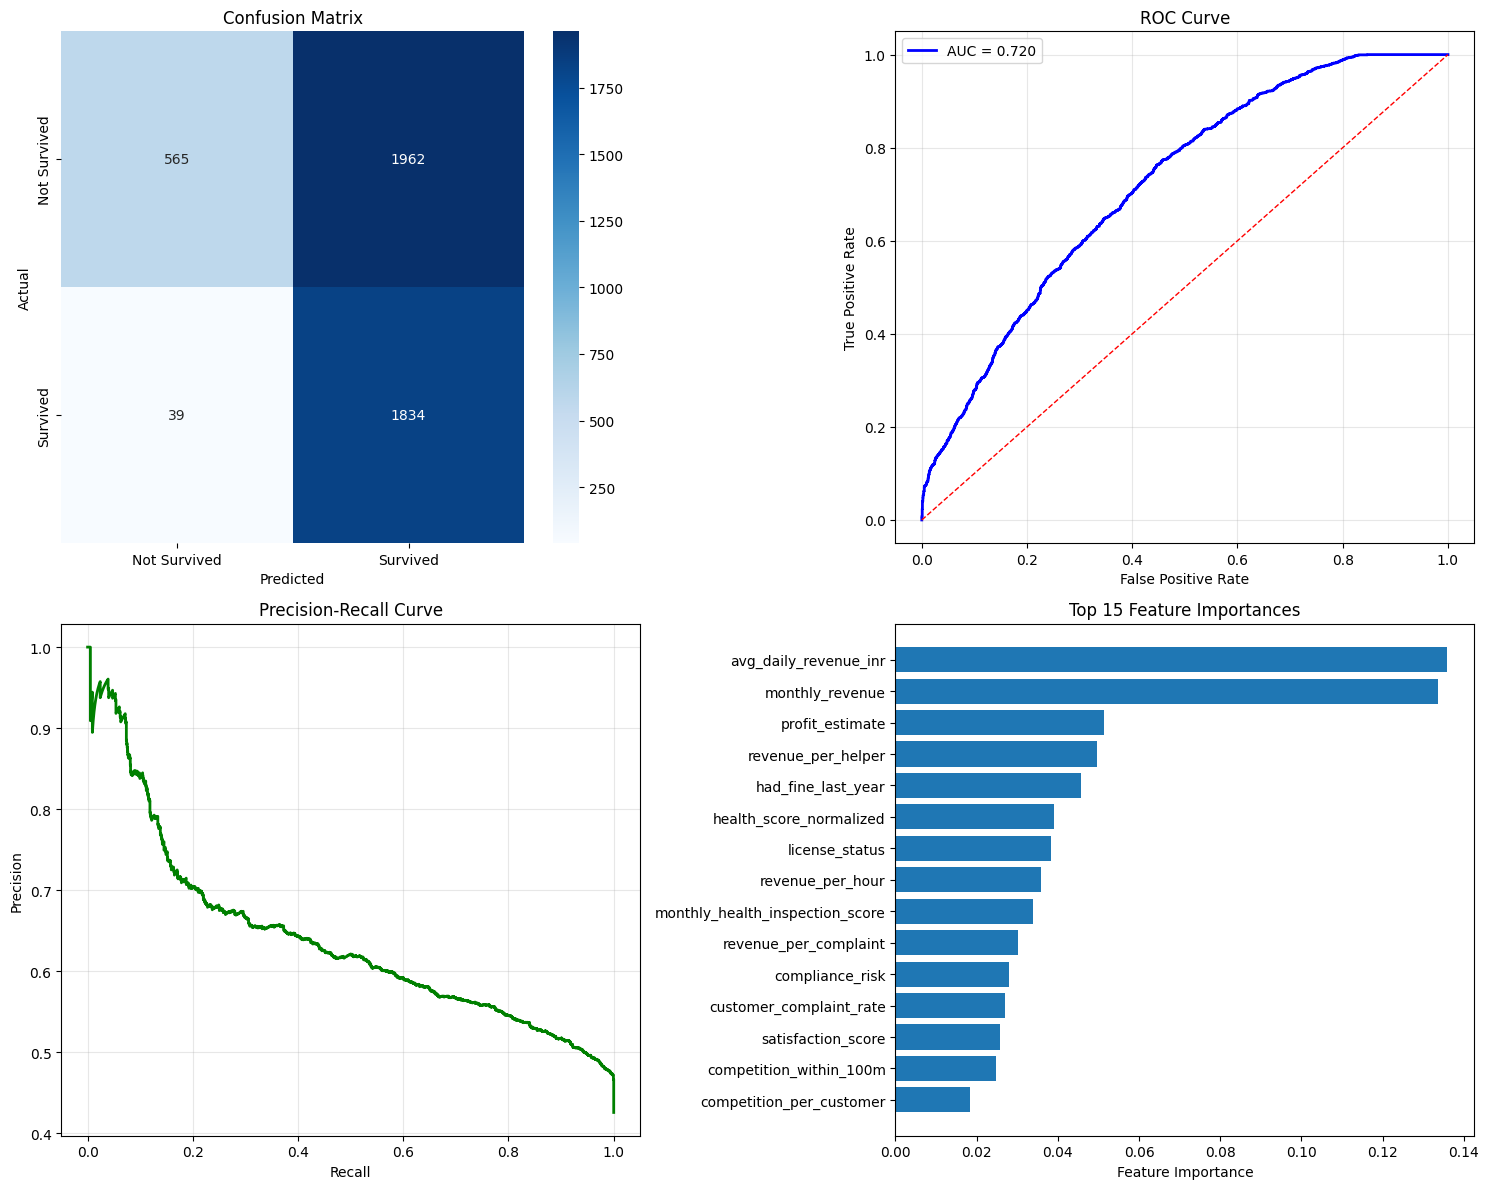

In [125]:
# Cell 21: Visualize model performance
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0,1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {metrics["AUC-ROC"]:.3f}')
axes[0,1].plot([0, 1], [0, 1], 'r--', linewidth=1)
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1,0].plot(recall, precision, 'g-', linewidth=2)
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curve')
axes[1,0].grid(True, alpha=0.3)

# 4. Feature Importance
feature_importance = pd.DataFrame({
    'feature': x_train.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

axes[1,1].barh(range(len(feature_importance)), feature_importance['importance'])
axes[1,1].set_yticks(range(len(feature_importance)))
axes[1,1].set_yticklabels(feature_importance['feature'])
axes[1,1].set_xlabel('Feature Importance')
axes[1,1].set_title('Top 15 Feature Importances')

plt.tight_layout()
plt.show()

In [126]:
precision,recall,thresholds=precision_recall_curve(y_test,y_pred_proba)

f1_scores=2 * (precision * recall) / (precision + recall + 1e-10)

optimal_idx=np.argmax(f1_scores[:-1])
optimal_threshold=thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

print(f"Optimal Classification Threshold: {optimal_threshold:.3f}")
print(f"Optimal F1 Score: {optimal_f1:.3f}")

y_pred_optimal=(y_pred_proba >= optimal_threshold).astype(int)

print("\nMetrics with optimal Threshold:")
print("-"*40)
print(f"Accuracy: {accuracy_score(y_test,y_pred_optimal):.4f}")
print(f"Precision: {precision_score(y_test,y_pred_optimal):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_optimal):.4f}")
# print(f"F1 Score: {f1_score(y_test, y_pred_optimal):.4f}")

Optimal Classification Threshold: 0.611
Optimal F1 Score: 0.658

Metrics with optimal Threshold:
----------------------------------------
Accuracy: 0.5959
Precision: 0.5143
Recall: 0.9151


In [ ]:
# """
# save_model_for_deployment.py
# Run this script in VS Code after training your model
# """

# import joblib
# import json
# import os
# import pandas as pd
# import numpy as np
# from datetime import datetime

# def save_model_for_streamlit(model, scaler, label_encoders, feature_names, optimal_threshold):
#     """
#     Save model specifically for Streamlit deployment
    
#     Parameters:
#     - model: trained XGBoost model
#     - scaler: fitted scaler
#     - label_encoders: dictionary of LabelEncoders
#     - feature_names: list of feature names
#     - optimal_threshold: float (optimal classification threshold)
#     """
    
#     # Create deployment directory
#     os.makedirs('deployment', exist_ok=True)
#     os.makedirs('deployment/model', exist_ok=True)
    
#     print("="*60)
#     print("SAVING MODEL FOR STREAMLIT DEPLOYMENT")
#     print("="*60)
    
#     # 1. Save model
#     joblib.dump(model, 'deployment/model/xgboost_model.pkl')
#     print("✓ Model saved: deployment/model/xgboost_model.pkl")
    
#     # 2. Save scaler
#     joblib.dump(scaler, 'deployment/model/scaler.pkl')
#     print("✓ Scaler saved: deployment/model/scaler.pkl")
    
#     # 3. Save label encoders
#     joblib.dump(label_encoders, 'deployment/model/label_encoders.pkl')
#     print("✓ Label encoders saved: deployment/model/label_encoders.pkl")
    
#     # 4. Save feature names
#     with open('deployment/model/feature_names.json', 'w') as f:
#         json.dump(feature_names, f, indent=4)
#     print("✓ Feature names saved: deployment/model/feature_names.json")
    
#     # 5. Save optimal threshold
#     with open('deployment/model/optimal_threshold.json', 'w') as f:
#         json.dump({'threshold': float(optimal_threshold)}, f, indent=4)
#     print("✓ Optimal threshold saved: deployment/model/optimal_threshold.json")
    
#     # 6. Save feature engineering function as a separate file
#     feature_engineering_code = '''
# import pandas as pd
# import numpy as np

# def create_features(df):
#     """Create advanced features for prediction"""
#     df_feat = df.copy()
    
#     # Business efficiency metrics
#     df_feat['revenue_per_customer'] = df_feat['avg_daily_revenue_inr'] / (df_feat['avg_daily_customers'] + 1)
#     df_feat['revenue_per_helper'] = df_feat['avg_daily_revenue_inr'] / (df_feat['num_helpers'] + 1)
#     df_feat['customers_per_helper'] = df_feat['avg_daily_customers'] / (df_feat['num_helpers'] + 1)
#     df_feat['customers_per_hour'] = df_feat['avg_daily_customers'] / (df_feat['hours_open_per_day'] + 1)
#     df_feat['revenue_per_hour'] = df_feat['avg_daily_revenue_inr'] / (df_feat['hours_open_per_day'] + 1)
    
#     # Experience metrics
#     df_feat['age_at_start'] = df_feat['vendor_age_years'] - df_feat['years_in_business']
#     df_feat['experience_ratio'] = df_feat['years_in_business'] / (df_feat['vendor_age_years'] + 1)
    
#     # Competition impact
#     df_feat['competition_per_customer'] = df_feat['competition_within_100m'] / (df_feat['avg_daily_customers'] + 1)
#     df_feat['market_saturation'] = df_feat['competition_within_100m'] * df_feat['hours_open_per_day']
    
#     # Profitability
#     df_feat['monthly_revenue'] = df_feat['avg_daily_revenue_inr'] * 30
#     df_feat['profit_estimate'] = df_feat['monthly_revenue'] - df_feat['monthly_stall_rent_inr']
#     df_feat['profit_margin'] = df_feat['profit_estimate'] / (df_feat['monthly_revenue'] + 1)
    
#     # Health and satisfaction
#     df_feat['health_score_normalized'] = df_feat['monthly_health_inspection_score'] / 100
#     df_feat['satisfaction_score'] = 1 - df_feat['customer_complaint_rate']
#     df_feat['rent_to_revenue_ratio'] = df_feat['monthly_stall_rent_inr'] / (df_feat['monthly_revenue'] + 1)
    
#     return df_feat
# '''
    
#     with open('deployment/feature_engineering.py', 'w') as f:
#         f.write(feature_engineering_code)
#     print("✓ Feature engineering saved: deployment/feature_engineering.py")
    
#     # 7. Save model info
#     model_info = {
#         'model_type': 'XGBoost Classifier',
#         'save_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
#         'n_features': len(feature_names),
#         'optimal_threshold': float(optimal_threshold),
#         'feature_names': feature_names[:10],  # First 10 features
#         'categorical_features': list(label_encoders.keys())
#     }
    
#     with open('deployment/model_info.json', 'w') as f:
#         json.dump(model_info, f, indent=4)
#     print("✓ Model info saved: deployment/model_info.json")
    
#     # 8. Create requirements file
#     requirements = '''
# streamlit==1.28.0
# pandas==2.0.3
# numpy==1.24.3
# scikit-learn==1.3.0
# xgboost==1.7.6
# plotly==5.17.0
# joblib==1.3.1
#     '''
    
#     with open('deployment/requirements.txt', 'w') as f:
#         f.write(requirements.strip())
#     print("✓ Requirements saved: deployment/requirements.txt")
    
#     # 9. Create a test script to verify saved model
#     test_script = '''
# import joblib
# import json
# import pandas as pd
# import numpy as np
# from feature_engineering import create_features

# def test_saved_model():
#     """Test if saved model works correctly"""
    
#     # Load model components
#     model = joblib.load('model/xgboost_model.pkl')
#     scaler = joblib.load('model/scaler.pkl')
#     label_encoders = joblib.load('model/label_encoders.pkl')
    
#     with open('model/feature_names.json', 'r') as f:
#         feature_names = json.load(f)
    
#     with open('model/optimal_threshold.json', 'r') as f:
#         threshold = json.load(f)['threshold']
    
#     # Test with sample data
#     test_data = pd.DataFrame({
#         'city': ['Delhi'],
#         'zone_type': ['Commercial'],
#         'food_category': ['Fast Food'],
#         'license_status': ['Licensed'],
#         'vendor_age_years': [35],
#         'years_in_business': [5],
#         'avg_daily_revenue_inr': [2500],
#         'avg_daily_customers': [120],
#         'monthly_stall_rent_inr': [5000],
#         'num_helpers': [2],
#         'hours_open_per_day': [10],
#         'competition_within_100m': [3],
#         'monthly_health_inspection_score': [85],
#         'had_fine_last_year': [0],
#         'avg_monthly_rainfall_mm': [100],
#         'season_of_observation': ['Summer'],
#         'has_online_presence': [1],
#         'customer_complaint_rate': [0.05]
#     })
    
#     # Create features
#     test_data = create_features(test_data)
    
#     # Encode categorical
#     for col, encoder in label_encoders.items():
#         if col in test_data.columns:
#             test_data[col] = test_data[col].astype(str)
#             test_data[col] = test_data[col].map(
#                 lambda x: encoder.transform([x])[0] if x in encoder.classes_ else -1
#             )
    
#     # Ensure all features exist
#     for col in feature_names:
#         if col not in test_data.columns:
#             test_data[col] = 0
    
#     # Scale and predict
#     X_test = test_data[feature_names]
#     X_test_scaled = scaler.transform(X_test)
    
#     probability = model.predict_proba(X_test_scaled)[0][1]
#     prediction = "Will Survive" if probability >= threshold else "May Not Survive"
    
#     print(f"Test Prediction: {prediction}")
#     print(f"Survival Probability: {probability:.1%}")
#     print("✅ Model test successful!")

# if __name__ == "__main__":
#     test_saved_model()
# '''
    
#     with open('deployment/test_model.py', 'w') as f:
#         f.write(test_script)
#     print("✓ Test script saved: deployment/test_model.py")
    
#     # 10. Create a zip file for easy download
#     import zipfile
#     zip_path = 'street_food_model_for_streamlit.zip'
#     with zipfile.ZipFile(zip_path, 'w') as zipf:
#         for root, dirs, files in os.walk('deployment'):
#             for file in files:
#                 file_path = os.path.join(root, file)
#                 arcname = os.path.relpath(file_path, 'deployment')
#                 zipf.write(file_path, arcname)
    
#     print(f"\n✓ All files zipped: {zip_path}")
    
#     print("\n" + "="*60)
#     print("✅ MODEL SAVED SUCCESSFULLY FOR STREAMLIT!")
#     print("="*60)
#     print("\n📁 Deployment folder structure:")
#     print("deployment/")
#     print("├── model/")
#     print("│   ├── xgboost_model.pkl")
#     print("│   ├── scaler.pkl")
#     print("│   ├── label_encoders.pkl")
#     print("│   ├── feature_names.json")
#     print("│   └── optimal_threshold.json")
#     print("├── feature_engineering.py")
#     print("├── model_info.json")
#     print("├── requirements.txt")
#     print("└── test_model.py")
#     print(f"\n📦 Zip file: {zip_path}")
#     print("\n🚀 Next: Copy the 'deployment' folder to your Streamlit project")
    
#     return zip_path

# # ============================================
# # AFTER TRAINING YOUR MODEL, RUN THIS:
# # ============================================

# # Assuming you have these variables from your training:
# # final_model, scaler, label_encoders, feature_names, optimal_threshold

# # Uncomment and run after training:
# # save_model_for_streamlit(final_model, scaler, label_encoders, 
# #                          feature_names, optimal_threshold)

In [128]:
import joblib
import json
import os

def save_model_for_deployment(model, scaler, label_encoders, feature_names, threshold=0.5):
    
    os.makedirs("deployment/model", exist_ok=True)

    # 1. Save model
    joblib.dump(model, "deployment/model/xgb_model.pkl")

    # 2. Save scaler
    joblib.dump(scaler, "deployment/model/scaler.pkl")

    # 3. Save encoders
    joblib.dump(label_encoders, "deployment/model/label_encoders.pkl")

    # 4. Save feature names
    with open("deployment/model/feature_names.json", "w") as f:
        json.dump(feature_names, f)

    # 5. Save threshold
    with open("deployment/model/threshold.json", "w") as f:
        json.dump({"threshold": threshold}, f)

    print("✅ Model saved for deployment")


# 👉 RUN THIS AFTER TRAINING
save_model_for_deployment(
    final_model,
    scaler,
    label_encoders,
    x_train.columns.tolist(),
    threshold=0.5
)

✅ Model saved for deployment
